# Training — Lasso & Ridge Regression for Parkinson's Severity

**Goal:** Predict Parkinson's disease severity from voice features and demographics.

| | Train (non-longitudinal) | Test (longitudinal) |
|---|---|---|
| Source | `cleaned_non_longitudinal_parkinson.parquet` | `cleaned_longitudinal_parkinson.parquet` |
| Rows | 1,876 | 493 |
| Patients | 56 | 6 (multiple sessions) |
| Target | `diagnosis_parkinsons_ds` (Hoehn & Yahr 1–5) | Same + Δ severity analysis |

**Two versions of features:**
- **Version A** — All features **except** `task_name` (dropped)
- **Version B** — `task_name` grouped into 5 categories → one-hot encoded

**Models:** Ridge and Lasso regression with GroupKFold CV (by patient)

**Key metric:** MAE

> **Note on delta targets:** The train set (non-longitudinal) has only one session per patient, so severity deltas cannot be computed. We train to predict absolute severity, then derive predicted deltas on the test set for comparison with actual `delta_voice_perception__voice_quality_perception`.

In [34]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# ── Load cleaned datasets ────────────────────────────────────────
DATA_DIR = Path("/home/srl/B2AI/LLM/data")

train_df = pd.read_parquet(DATA_DIR / "cleaned_non_longitudinal_parkinson.parquet")
test_df  = pd.read_parquet(DATA_DIR / "cleaned_longitudinal_parkinson.parquet")


## 1. Feature Extraction

Linear models require fixed-length numeric input. The audio arrays are 2-D:
- **MFCC**: `(180, T)` — 60 static + 60 Δ + 60 ΔΔ coefficients × variable time frames
- **Mel spectrogram**: `(60, 512)` — 60 frequency bins × 512 fixed frames

**Extraction strategy** — per-coefficient/bin **mean** and **std** across time:

| Source | Stats | Features |
|--------|-------|----------|
| MFCC (180 coefficients) | mean + std | 360 |
| Mel spectrogram (60 bins) | mean + std | 120 |
| Tabular (demographics, clinical) | as-is | ~63 |
| **Total** | | **~543** |

In [36]:
# ══════════════════════════════════════════════════════════════════
#  1. Extract MFCC summary statistics + assemble feature matrices
# ══════════════════════════════════════════════════════════════════

def _to_2d(x):
    """Convert a single mfcc cell (from parquet) to 2D float32 array (coeffs, T)."""
    # Already a proper 2D ndarray
    if isinstance(x, np.ndarray) and x.ndim == 2:
        return x.astype(np.float32)
    # From parquet: x is a list whose elements may be lists or np arrays
    # Stack row-by-row to avoid the ragged-array error
    rows = [np.asarray(row, dtype=np.float32) for row in x]
    return np.stack(rows)  # → (coeffs, T)

def extract_mfcc_features(df, name):
    """Per-coefficient mean & std across time → fixed-length feature vector."""
    # Quick diagnostic: check first few shapes
    shapes = [_to_2d(x).shape for x in df["mfcc"].head(5)]
    print(f"  [{name}] Sample MFCC shapes: {shapes}")

    mfcc_mean = np.stack([_to_2d(x).mean(axis=1) for x in df["mfcc"]])
    mfcc_std  = np.stack([_to_2d(x).std(axis=1)  for x in df["mfcc"]])

    cols = ([f"mfcc_mean_{i}" for i in range(mfcc_mean.shape[1])] +
            [f"mfcc_std_{i}"  for i in range(mfcc_std.shape[1])])

    audio_df = pd.DataFrame(
        np.hstack([mfcc_mean, mfcc_std]),
        columns=cols, index=df.index,
    )
    print(f"  [{name}] MFCC features: {audio_df.shape[1]}")
    return audio_df

train_audio = extract_mfcc_features(train_df, "train")
test_audio  = extract_mfcc_features(test_df,  "test")

# ── Tabular features (exclude IDs, audio arrays, targets) ────────
EXCLUDE = {"participant_id", "session_id", "task_name",
           "mfcc", "mel_spectrogram",
           "diagnosis_parkinsons_ds",
           "delta_voice_perception",
           "session_order"}

tabular_cols = [c for c in train_df.columns
                if c not in EXCLUDE and pd.api.types.is_numeric_dtype(train_df[c])]

# ── Combine tabular + audio ──────────────────────────────────────
X_train_base = pd.concat([train_df[tabular_cols].reset_index(drop=True),
                           train_audio.reset_index(drop=True)], axis=1)
X_test_base  = pd.concat([test_df[tabular_cols].reset_index(drop=True),
                           test_audio.reset_index(drop=True)], axis=1)

# Target
y_train = train_df["diagnosis_parkinsons_ds"].values.astype(float)
y_test  = test_df["delta_voice_perception"].values.astype(float)

# Patient groups for GroupKFold (no data leakage)
train_groups = train_df["participant_id"].values

# ── Sanity checks ────────────────────────────────────────────────
assert X_train_base.isna().sum().sum() == 0, "NaN in train features!"
assert X_test_base.isna().sum().sum() == 0, "NaN in test features!"

print(f"\nTabular features: {len(tabular_cols)}")
print(f"MFCC features:    {train_audio.shape[1]}")
print(f"Total features:   {X_train_base.shape[1]}")
print(f"\nX_train: {X_train_base.shape}  |  y_train: {y_train.shape}")
print(f"X_test:  {X_test_base.shape}  |  y_test:  {y_test.shape}")

  [train] Sample MFCC shapes: [(180, 3278), (180, 558), (180, 711), (180, 513), (180, 585)]
  [train] MFCC features: 360
  [test] Sample MFCC shapes: [(180, 1275), (180, 6252), (180, 227), (180, 141), (180, 141)]
  [test] MFCC features: 360

Tabular features: 67
MFCC features:    360
Total features:   427

X_train: (1876, 427)  |  y_train: (1876,)
X_test:  (493, 427)  |  y_test:  (493,)


## 2. Task Name Grouping (Version B)

120 unique task names grouped into **5 clinically meaningful categories**:

| Group | Tasks included |
|-------|---------------|
| **sustained_phonation** | prolonged vowel, max phonation time, glides, loudness |
| **read_speech** | rainbow passage, harvard sentences, cinderella story, CAPE-V, caterpillar |
| **diadochokinesis** | diadochokinesis (pa, ta, ka, pataka, buttercup) |
| **respiration** | breath sounds, respiration & cough, voluntary cough |
| **cognitive_vocal** | animal fluency, picture description, story recall, productive vocabulary, Stroop, random item generation |

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  2. Task name grouping + feature matrix variants
# ══════════════════════════════════════════════════════════════════

TASK_GROUPS = {
    "sustained_phonation": ["prolonged-vowel", "maximum-phonation-time",
                            "glides-", "loudness"],
    "read_speech":         ["rainbow-passage", "caterpillar-passage",
                            "harvard-sentences", "cape-v-sentences",
                            "cinderella-story"],
    "diadochokinesis":     ["diadochokinesis"],
    "respiration":         ["breath-sounds", "respiration-and-cough",
                            "voluntary-cough"],
    "cognitive_vocal":     ["animal-fluency", "word-color-stroop",
                            "random-item-generation", "picture-description",
                            "story-recall", "productive-vocabulary"],
}

def map_task_group(task_name):
    for group, prefixes in TASK_GROUPS.items():
        for prefix in prefixes:
            if task_name.startswith(prefix):
                return group
    return "other"

train_df["task_group"] = train_df["task_name"].apply(map_task_group)
test_df["task_group"]  = test_df["task_name"].apply(map_task_group)

print("Task group distribution:")
for label, df_tmp in [("Train", train_df), ("Test", test_df)]:
    print(f"\n  {label}:")
    for g, cnt in df_tmp["task_group"].value_counts().sort_index().items():
        print(f"    {g:25s}  {cnt}")

# ── One-hot encode task groups ────────────────────────────────────
train_task_oh = pd.get_dummies(train_df["task_group"], prefix="task").astype(float)
test_task_oh  = pd.get_dummies(test_df["task_group"],  prefix="task").astype(float)

# Align columns (ensure same set in train and test)
all_task_cols = sorted(set(train_task_oh.columns) | set(test_task_oh.columns))
for c in all_task_cols:
    if c not in train_task_oh.columns:
        train_task_oh[c] = 0.0
    if c not in test_task_oh.columns:
        test_task_oh[c] = 0.0
train_task_oh = train_task_oh[all_task_cols]
test_task_oh  = test_task_oh[all_task_cols]

# ── Version A: base features only (no task_name) ─────────────────
X_train_A = X_train_base.copy()
X_test_A  = X_test_base.copy()

# ── Version B: base features + task group one-hot ─────────────────
X_train_B = pd.concat([X_train_base.reset_index(drop=True),
                        train_task_oh.reset_index(drop=True)], axis=1)
X_test_B  = pd.concat([X_test_base.reset_index(drop=True),
                        test_task_oh.reset_index(drop=True)], axis=1)

print(f"\nVersion A features: {X_train_A.shape[1]}")
print(f"Version B features: {X_train_B.shape[1]}  "
      f"(+{X_train_B.shape[1] - X_train_A.shape[1]} task columns: "
      f"{all_task_cols})")

Task group distribution:

  Train:
    cognitive_vocal            530
    diadochokinesis            270
    read_speech                165
    respiration                533
    sustained_phonation        378

  Test:
    cognitive_vocal            142
    diadochokinesis            70
    read_speech                46
    respiration                139
    sustained_phonation        96

Version A features: 427
Version B features: 432  (+5 task columns: ['task_cognitive_vocal', 'task_diadochokinesis', 'task_read_speech', 'task_respiration', 'task_sustained_phonation'])


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  3. Train Ridge & Lasso — both versions
# ══════════════════════════════════════════════════════════════════

def eval_metrics(y_true, y_pred):
    """Compute MAE, RMSE, R²."""
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²":   r2_score(y_true, y_pred),
    }

alphas = np.logspace(-3, 6, 50)
gkf = GroupKFold(n_splits=5)

results = []
predictions = {}          # key → test predictions (for delta analysis later)
best_estimators = {}      # key → fitted pipeline

versions = [
    ("A (no task_name)", X_train_A, X_test_A),
    ("B (task groups)",  X_train_B, X_test_B),
]

models_cfg = [
    ("Ridge", Ridge(),              {"model__alpha": alphas}),
    ("Lasso", Lasso(max_iter=10000), {"model__alpha": alphas}),
]

for ver_name, X_tr, X_te in versions:
    print(f"\n{'═' * 70}")
    print(f"  Version {ver_name}  —  {X_tr.shape[1]} features")
    print(f"{'═' * 70}")

    for mod_name, mod, params in models_cfg:
        pipe = Pipeline([("scaler", StandardScaler()), ("model", mod)])

        gs = GridSearchCV(
            pipe, params, cv=gkf,
            scoring="neg_mean_absolute_error",
            n_jobs=-1, refit=True,
        )
        gs.fit(X_tr, y_train, groups=train_groups)
        best_alpha = gs.best_params_["model__alpha"]

        # Out-of-fold predictions on train (unbiased estimate)
        y_tr_pred = cross_val_predict(
            gs.best_estimator_, X_tr, y_train, cv=gkf, groups=train_groups
        )
        # Test predictions
        y_te_pred = gs.predict(X_te)

        # Store
        key = f"{mod_name}_v{ver_name[0]}"
        predictions[key] = y_te_pred
        best_estimators[key] = gs.best_estimator_

        # Metrics
        tr_m = eval_metrics(y_train, y_tr_pred)
        te_m = eval_metrics(y_test,  y_te_pred)

        print(f"\n  {mod_name}  (best α = {best_alpha:.2e})")
        print(f"    Train (CV):  MAE={tr_m['MAE']:.4f}  "
              f"RMSE={tr_m['RMSE']:.4f}  R²={tr_m['R²']:.4f}")
        print(f"    Test:        MAE={te_m['MAE']:.4f}  "
              f"RMSE={te_m['RMSE']:.4f}  R²={te_m['R²']:.4f}")

        if mod_name == "Lasso":
            coefs = gs.best_estimator_.named_steps["model"].coef_
            n_nz = np.sum(coefs != 0)
            print(f"    Non-zero coefficients: {n_nz}/{len(coefs)}")

        results.append({
            "Model": mod_name, "Version": ver_name, "α": best_alpha,
            "Train MAE": tr_m["MAE"], "Train RMSE": tr_m["RMSE"],
            "Train R²": tr_m["R²"],
            "Test MAE": te_m["MAE"], "Test RMSE": te_m["RMSE"],
            "Test R²": te_m["R²"],
        })


══════════════════════════════════════════════════════════════════════
  Version A (no task_name)  —  427 features
══════════════════════════════════════════════════════════════════════

  Ridge  (best α = 6.25e+03)
    Train (CV):  MAE=0.8095  RMSE=1.0030  R²=0.0329
    Test:        MAE=0.8895  RMSE=1.0782  R²=0.0159

  Lasso  (best α = 1.60e-01)
    Train (CV):  MAE=0.7959  RMSE=0.9933  R²=0.0516
    Test:        MAE=0.7913  RMSE=0.9848  R²=0.1791
    Non-zero coefficients: 7/427

══════════════════════════════════════════════════════════════════════
  Version B (task groups)  —  432 features
══════════════════════════════════════════════════════════════════════

  Ridge  (best α = 6.25e+03)
    Train (CV):  MAE=0.8103  RMSE=1.0035  R²=0.0320
    Test:        MAE=0.8904  RMSE=1.0787  R²=0.0151

  Lasso  (best α = 1.60e-01)
    Train (CV):  MAE=0.7959  RMSE=0.9933  R²=0.0516
    Test:        MAE=0.7913  RMSE=0.9848  R²=0.1791
    Non-zero coefficients: 7/432


## 4. Severity Prediction Results (intermediate)

How well does each model predict **absolute severity** on test? This is the intermediate step — good severity prediction is a prerequisite for good Δ prediction.

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  4. Results summary table
# ══════════════════════════════════════════════════════════════════

results_df = pd.DataFrame(results)

display(
    results_df.style
    .format({
        "α": "{:.2e}",
        "Train MAE": "{:.4f}", "Train RMSE": "{:.4f}", "Train R²": "{:.4f}",
        "Test MAE":  "{:.4f}", "Test RMSE":  "{:.4f}", "Test R²":  "{:.4f}",
    })
    .highlight_min(subset=["Test MAE", "Test RMSE"], color="#b7e4c7")
    .highlight_max(subset=["Test R²"], color="#b7e4c7")
)

# ── Best model ────────────────────────────────────────────────────
best_idx = results_df["Test MAE"].idxmin()
best = results_df.loc[best_idx]
print(f"\n✅  Best model by Test MAE:")
print(f"   {best['Model']} — Version {best['Version']}")
print(f"   α = {best['α']:.2e}")
print(f"   Test MAE  = {best['Test MAE']:.4f}")
print(f"   Test RMSE = {best['Test RMSE']:.4f}")
print(f"   Test R²   = {best['Test R²']:.4f}")

,Model,Version,α,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²
0,Ridge,A (no task_name),6.25e+03,0.8095,1.0030,0.0329,0.8895,1.0782,0.0159
1,Lasso,A (no task_name),1.60e-01,0.7959,0.9933,0.0516,0.7913,0.9848,0.1791
2,Ridge,B (task groups),6.25e+03,0.8103,1.0035,0.0320,0.8904,1.0787,0.0151
3,Lasso,B (task groups),1.60e-01,0.7959,0.9933,0.0516,0.7913,0.9848,0.1791



✅  Best model by Test MAE:
   Lasso — Version A (no task_name)
   α = 1.60e-01
   Test MAE  = 0.7913
   Test RMSE = 0.9848
   Test R²   = 0.1791


## 5. Δ Severity Evaluation (primary target)

This is the **actual evaluation**. For each model:

1. Predict severity for every recording in the test set
2. Average predictions per session (each session has ~35 task recordings)
3. Compute **Δ_predicted = mean_pred(session n) − mean_pred(session n−1)**
4. Compare with actual `delta_voice_perception__voice_quality_perception`

**Metrics:**
- **MAE** — primary metric (how far off are the predicted deltas?)
- **RMSE** — penalises large errors more
- **Spearman ρ** — does the model get the direction/ranking of changes right?
- **Pearson r** — linear correlation

> **Note:** The predicted Δ is on the H&Y scale while the actual Δ is on the voice perception scale. MAE across different scales still measures prediction quality in absolute terms; correlation measures whether the model captures the *direction* of change.

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  5. Δ Severity evaluation — delta_voice_perception
# ══════════════════════════════════════════════════════════════════
from scipy.stats import spearmanr, pearsonr

DELTA_COL = "delta_voice_perception"

# ── Helper: rescale predicted Δ (H&Y) to actual Δ scale ──────────
def rescale(pred, actual):
    """z-score rescaling: match mean & std of actual."""
    p_std = pred.std()
    if p_std < 1e-8:
        return pred * 0 + actual.mean()
    return (pred - pred.mean()) / p_std * actual.std() + actual.mean()

# ── Build working DataFrame with test metadata ───────────────────
test_eval = test_df[["participant_id", "session_id", "session_order",
                      DELTA_COL]].copy()

delta_results = []

for key, y_pred in predictions.items():
    # ── 1. Average predicted severity per session ─────────────────
    test_eval["_pred"] = y_pred
    sess_pred = (test_eval.groupby(["participant_id", "session_order"])["_pred"]
                 .mean().reset_index())

    # ── 2. Compute predicted Δ per patient (consecutive sessions) ─
    pred_deltas = []
    for pid, grp in sess_pred.groupby("participant_id"):
        grp = grp.sort_values("session_order")
        grp["pred_delta"] = grp["_pred"].diff()
        pred_deltas.append(grp)
    pred_delta_df = pd.concat(pred_deltas)

    # ── 3. Merge actual Δ with predicted Δ ────────────────────────
    actual = (test_eval.groupby(["participant_id", "session_order"])
              [DELTA_COL].first().reset_index())

    merged = actual.merge(
        pred_delta_df[["participant_id", "session_order", "pred_delta"]],
        on=["participant_id", "session_order"],
    )
    merged = merged.dropna()

    y_actual = merged[DELTA_COL].values
    y_pdelta = merged["pred_delta"].values

    if len(merged) < 3:
        print(f"  {key:20s}  N={len(merged)} — too few points, skipped")
        continue

    # ── 4. Correlation metrics (scale-free — most reliable) ──────
    sp_corr, sp_p = spearmanr(y_actual, y_pdelta)
    pe_corr, pe_p = pearsonr(y_actual, y_pdelta)

    # ── 5. Rescale predicted Δ to voice perception scale ─────────
    y_pdelta_rs = rescale(y_pdelta, y_actual)
    mae_rs  = mean_absolute_error(y_actual, y_pdelta_rs)
    rmse_rs = np.sqrt(mean_squared_error(y_actual, y_pdelta_rs))

    # Naive baseline: always predict Δ = 0 (no change)
    naive_mae  = mean_absolute_error(y_actual, np.zeros_like(y_actual))
    naive_rmse = np.sqrt(mean_squared_error(y_actual, np.zeros_like(y_actual)))

    delta_results.append({
        "Model": key, "N": len(merged),
        "Spearman ρ": round(sp_corr, 4), "Spearman p": round(sp_p, 4),
        "Pearson r":  round(pe_corr, 4), "Pearson p":  round(pe_p, 4),
        "MAE (rescaled)":  round(mae_rs, 4),
        "RMSE (rescaled)": round(rmse_rs, 4),
        "Naive MAE":  round(naive_mae, 4),
        "Naive RMSE": round(naive_rmse, 4),
    })

    print(f"  {key:20s}  N={len(merged):3d}  "
          f"Spearman={sp_corr:+.3f}  Pearson={pe_corr:+.3f}  "
          f"MAE_rs={mae_rs:.3f}  (naive={naive_mae:.3f})")

test_eval.drop(columns=["_pred"], inplace=True)

# ══════════════════════════════════════════════════════════════════
#  Summary table
# ══════════════════════════════════════════════════════════════════
print()
delta_results_df = pd.DataFrame(delta_results)

display(
    delta_results_df.style
    .format({
        "Spearman ρ": "{:+.4f}", "Spearman p": "{:.4f}",
        "Pearson r": "{:+.4f}",  "Pearson p": "{:.4f}",
        "MAE (rescaled)": "{:.4f}", "RMSE (rescaled)": "{:.4f}",
        "Naive MAE": "{:.4f}", "Naive RMSE": "{:.4f}",
    })
    .highlight_max(subset=["Spearman ρ", "Pearson r"], color="#b7e4c7")
    .highlight_min(subset=["MAE (rescaled)", "RMSE (rescaled)"], color="#b7e4c7")
)

# ── Best model (by Spearman ρ) ────────────────────────────────────
if not delta_results_df.empty:
    best_d = delta_results_df.loc[delta_results_df["Spearman ρ"].idxmax()]
    naive_mae = best_d["Naive MAE"]
    print(f"\n✅  Best model by Spearman ρ:")
    print(f"   {best_d['Model']}")
    print(f"   Spearman ρ       = {best_d['Spearman ρ']:+.4f}  (p={best_d['Spearman p']:.4f})")
    print(f"   Pearson r        = {best_d['Pearson r']:+.4f}")
    print(f"   MAE (rescaled)   = {best_d['MAE (rescaled)']:.4f}  "
          f"(naive baseline = {naive_mae:.4f}  →  "
          f"{'✓ beats' if best_d['MAE (rescaled)'] < naive_mae else '✗ worse than'} naive)")
    print(f"   RMSE (rescaled)  = {best_d['RMSE (rescaled)']:.4f}")

  Ridge_vA              N=  8  Spearman=+0.446  Pearson=+0.423  MAE_rs=2.083  (naive=2.000)
  Lasso_vA              N=  8  Spearman=-0.501  Pearson=-0.540  MAE_rs=3.282  (naive=2.000)
  Ridge_vB              N=  8  Spearman=+0.446  Pearson=+0.447  MAE_rs=2.066  (naive=2.000)
  Lasso_vB              N=  8  Spearman=-0.501  Pearson=-0.540  MAE_rs=3.282  (naive=2.000)



,Model,N,Spearman ρ,Spearman p,Pearson r,Pearson p,MAE (rescaled),RMSE (rescaled),Naive MAE,Naive RMSE
0,Ridge_vA,8,+0.4458,0.2683,+0.4231,0.2963,2.0830,2.6312,2.0000,2.5000
1,Lasso_vA,8,-0.5009,0.2061,-0.5401,0.1671,3.2823,4.2989,2.0000,2.5000
2,Ridge_vB,8,+0.4458,0.2683,+0.4471,0.2667,2.0659,2.5758,2.0000,2.5000
3,Lasso_vB,8,-0.5009,0.2061,-0.5401,0.1671,3.2823,4.2989,2.0000,2.5000



✅  Best model by Spearman ρ:
   Ridge_vA
   Spearman ρ       = +0.4458  (p=0.2683)
   Pearson r        = +0.4231
   MAE (rescaled)   = 2.0830  (naive baseline = 2.0000  →  ✗ worse than naive)
   RMSE (rescaled)  = 2.6312


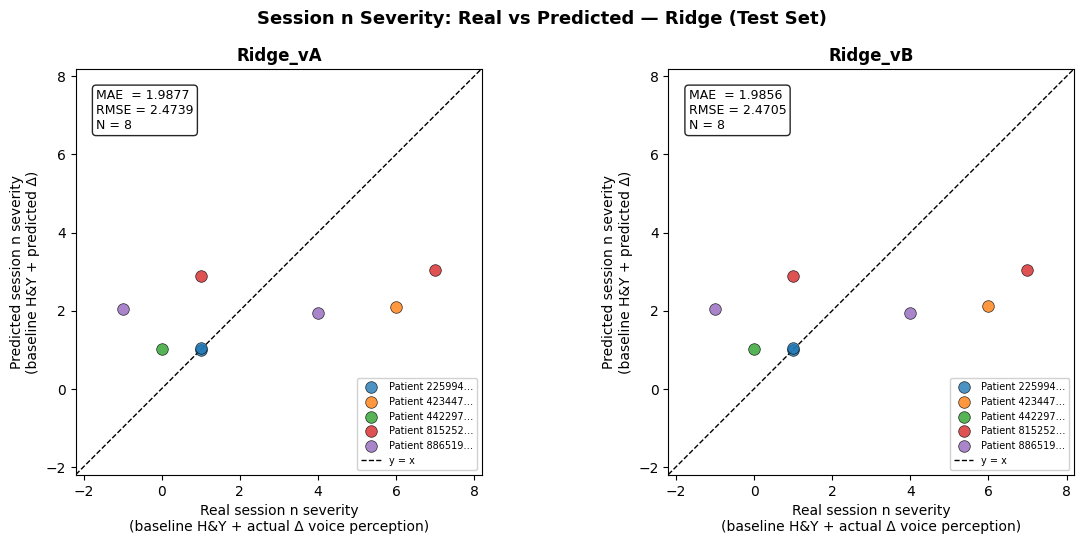

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  6. Session n severity: real vs predicted — Ridge only
# ══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

DELTA_COL = "delta_voice_perception"
SEV_COL   = "diagnosis_parkinsons_ds"
ridge_keys = [k for k in predictions if k.startswith("Ridge")]

fig, axes = plt.subplots(1, len(ridge_keys),
                         figsize=(6 * len(ridge_keys), 5.5), squeeze=False)

# ── Per-session actual severity & predicted severity ──────────────
test_work = test_df[["participant_id", "session_id", "session_order",
                      SEV_COL, DELTA_COL]].copy()

for j, key in enumerate(ridge_keys):
    ax = axes[0, j]

    # Average predicted severity per session
    test_work["_pred"] = predictions[key]
    sess = (test_work
            .groupby(["participant_id", "session_order"])
            .agg(_pred=(     "_pred", "mean"),
                 sev_actual=(SEV_COL, "first"),
                 delta_actual=(DELTA_COL, "first"))
            .reset_index())

    # For each session n (n>=2), get severity at session n-1 (baseline)
    rows = []
    for pid, grp in sess.groupby("participant_id"):
        grp = grp.sort_values("session_order").reset_index(drop=True)
        for idx in range(1, len(grp)):
            baseline = grp.loc[idx - 1, "sev_actual"]      # severity at session n-1
            actual_delta = grp.loc[idx, "delta_actual"]     # actual Δ
            pred_delta   = grp.loc[idx, "_pred"] - grp.loc[idx - 1, "_pred"]  # predicted Δ

            real_next = baseline + actual_delta              # session n real
            pred_next = baseline + pred_delta                # session n predicted

            rows.append({
                "participant_id": pid,
                "session_order": grp.loc[idx, "session_order"],
                "baseline": baseline,
                "real_next": real_next,
                "pred_next": pred_next,
            })

    plot_df = pd.DataFrame(rows).dropna()

    # ── Scatter, colored by patient ───────────────────────────────
    unique_pids = sorted(plot_df["participant_id"].unique())
    cmap = plt.cm.tab10
    for i, pid in enumerate(unique_pids):
        sub = plot_df[plot_df["participant_id"] == pid]
        ax.scatter(sub["real_next"], sub["pred_next"],
                   alpha=0.8, s=70, edgecolors="k", linewidths=0.5,
                   zorder=3, color=cmap(i), label=f"Patient {pid[:6]}…")

    # ── Identity & reference lines ────────────────────────────────
    all_vals = np.concatenate([plot_df["real_next"].values,
                                plot_df["pred_next"].values])
    margin = max(0.3, (all_vals.max() - all_vals.min()) * 0.15)
    lo, hi = all_vals.min() - margin, all_vals.max() + margin
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="y = x")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    ax.set_xlabel("Real session n severity\n(baseline H&Y + actual Δ voice perception)", fontsize=10)
    ax.set_ylabel("Predicted session n severity\n(baseline H&Y + predicted Δ)", fontsize=10)
    ax.set_title(f"{key}", fontsize=12, fontweight="bold")

    # ── Metrics ───────────────────────────────────────────────────
    if len(plot_df) >= 2:
        mae  = mean_absolute_error(plot_df["real_next"], plot_df["pred_next"])
        rmse = np.sqrt(mean_squared_error(plot_df["real_next"], plot_df["pred_next"]))
        ax.text(0.05, 0.95,
                f"MAE  = {mae:.4f}\nRMSE = {rmse:.4f}\nN = {len(plot_df)}",
                transform=ax.transAxes, va="top", fontsize=9,
                bbox=dict(boxstyle="round", fc="white", alpha=0.85))

    ax.legend(loc="lower right", fontsize=7, framealpha=0.9)
    ax.set_aspect("equal", adjustable="box")

test_work.drop(columns=["_pred"], inplace=True)

fig.suptitle("Session n Severity: Real vs Predicted — Ridge (Test Set)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

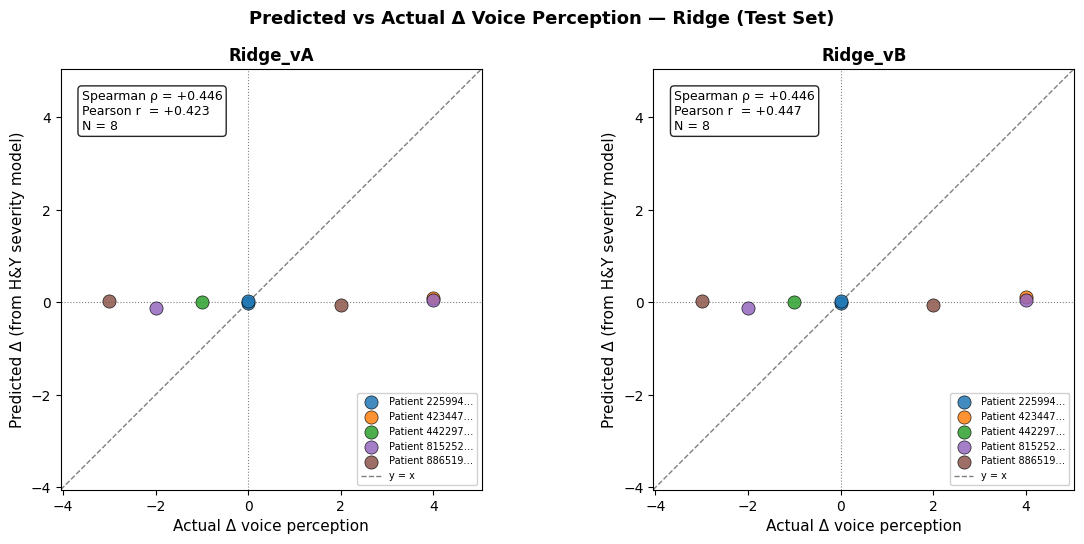

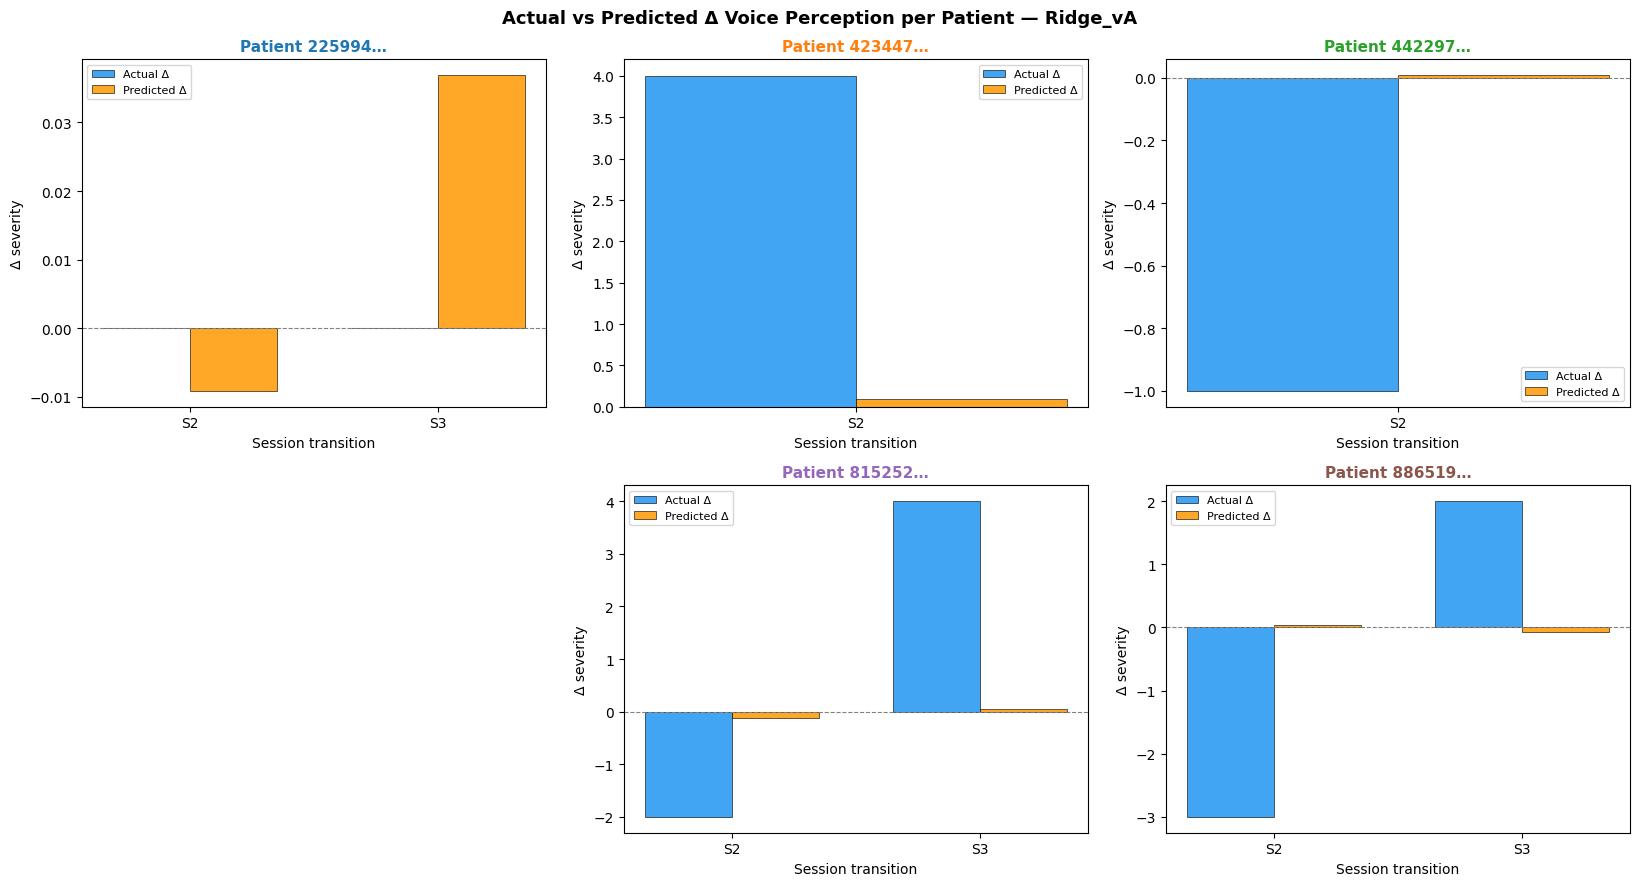

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  7. Predicted vs Actual Δ voice perception — per patient (Ridge)
# ══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

DELTA_COL = "delta_voice_perception"
ridge_keys = [k for k in predictions if k.startswith("Ridge")]

# ── Build predicted deltas for all Ridge models ──────────────────
test_work = test_df[["participant_id", "session_id", "session_order",
                      DELTA_COL]].copy()

all_model_data = {}
for key in ridge_keys:
    test_work["_pred"] = predictions[key]
    sess = (test_work
            .groupby(["participant_id", "session_order"])
            .agg(_pred=("_pred", "mean"),
                 delta_actual=(DELTA_COL, "first"))
            .reset_index())

    rows = []
    for pid, grp in sess.groupby("participant_id"):
        grp = grp.sort_values("session_order").reset_index(drop=True)
        for idx in range(1, len(grp)):
            pred_delta = grp.loc[idx, "_pred"] - grp.loc[idx - 1, "_pred"]
            rows.append({
                "participant_id": pid,
                "session_order": grp.loc[idx, "session_order"],
                "actual_delta": grp.loc[idx, "delta_actual"],
                "pred_delta": pred_delta,
            })
    all_model_data[key] = pd.DataFrame(rows).dropna()

test_work.drop(columns=["_pred"], inplace=True)

# ── Get unique patients ──────────────────────────────────────────
patients = sorted(test_df["participant_id"].unique())
n_patients = len(patients)
cmap = plt.cm.tab10

# ══════════════════════════════════════════════════════════════════
#  Plot 1: Scatter — Predicted Δ vs Actual Δ (per patient, Ridge)
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, len(ridge_keys),
                         figsize=(6 * len(ridge_keys), 5.5), squeeze=False)

for j, key in enumerate(ridge_keys):
    ax = axes[0, j]
    df = all_model_data[key]

    for i, pid in enumerate(patients):
        sub = df[df["participant_id"] == pid]
        if sub.empty:
            continue
        ax.scatter(sub["actual_delta"], sub["pred_delta"],
                   color=cmap(i), s=90, edgecolors="k", linewidths=0.5,
                   zorder=3, alpha=0.85,
                   label=f"Patient {pid[:8]}…")

    # Identity line
    all_vals = np.concatenate([df["actual_delta"].values,
                                df["pred_delta"].values])
    margin = max(0.5, (all_vals.max() - all_vals.min()) * 0.15)
    lo, hi = all_vals.min() - margin, all_vals.max() + margin
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.5, label="y = x")
    ax.axhline(0, color="gray", ls=":", lw=0.8)
    ax.axvline(0, color="gray", ls=":", lw=0.8)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    ax.set_xlabel("Actual Δ voice perception", fontsize=11)
    ax.set_ylabel("Predicted Δ (from H&Y severity model)", fontsize=11)
    ax.set_title(key, fontsize=12, fontweight="bold")
    ax.legend(loc="lower right", fontsize=7, framealpha=0.9)
    ax.set_aspect("equal", adjustable="box")

    # Metrics
    if len(df) >= 2:
        sp, _ = spearmanr(df["actual_delta"], df["pred_delta"])
        pe, _ = pearsonr(df["actual_delta"], df["pred_delta"])
        ax.text(0.05, 0.95,
                f"Spearman ρ = {sp:+.3f}\nPearson r  = {pe:+.3f}\nN = {len(df)}",
                transform=ax.transAxes, va="top", fontsize=9,
                bbox=dict(boxstyle="round", fc="white", alpha=0.85))

fig.suptitle("Predicted vs Actual Δ Voice Perception — Ridge (Test Set)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════
#  Plot 2: Per-patient subplots — Actual vs Predicted Δ per session
# ══════════════════════════════════════════════════════════════════
# Use best Ridge model
best_ridge = ridge_keys[0]
df_plot = all_model_data[best_ridge]

n_cols = min(3, n_patients)
n_rows = (n_patients + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5.5 * n_cols, 4.5 * n_rows),
                         squeeze=False)

for idx, pid in enumerate(patients):
    r, c = divmod(idx, n_cols)
    ax = axes[r][c]
    sub = df_plot[df_plot["participant_id"] == pid].sort_values("session_order")

    if sub.empty:
        ax.set_visible(False)
        continue

    sessions = sub["session_order"].values
    x_pos = np.arange(len(sessions))

    bar_w = 0.35
    ax.bar(x_pos - bar_w/2, sub["actual_delta"].values, bar_w,
           color="#2196F3", edgecolor="k", linewidth=0.5, label="Actual Δ", alpha=0.85)
    ax.bar(x_pos + bar_w/2, sub["pred_delta"].values, bar_w,
           color="#FF9800", edgecolor="k", linewidth=0.5, label="Predicted Δ", alpha=0.85)

    ax.axhline(0, color="gray", ls="--", lw=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"S{int(s)}" for s in sessions])
    ax.set_xlabel("Session transition", fontsize=10)
    ax.set_ylabel("Δ severity", fontsize=10)
    ax.set_title(f"Patient {pid[:8]}…", fontsize=11, fontweight="bold",
                 color=cmap(idx))
    ax.legend(fontsize=8)

# Hide unused subplots
for idx in range(n_patients, n_rows * n_cols):
    r, c = divmod(idx, n_cols)
    axes[r][c].set_visible(False)

fig.suptitle(f"Actual vs Predicted Δ Voice Perception per Patient — {best_ridge}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()